# 1. Imports and Library Setup
We import all necessary libraries for data manipulation, visualization, and machine learning.


In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from tqdm.notebook import tqdm
import shap
import inspect




In [76]:
# --- Helper Functions: Dual Learning Curves (F1 & Loss) ---
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss

def plot_dual_learning_curves(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{title} - Cross-Validation Performance", fontsize=16)
    
    # --- F1 Score Curve ---
    train_sizes_f1, train_scores_f1, test_scores_f1 = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='f1_weighted'
    )
    
    train_mean_f1 = np.mean(train_scores_f1, axis=1)
    train_std_f1 = np.std(train_scores_f1, axis=1)
    test_mean_f1 = np.mean(test_scores_f1, axis=1)
    test_std_f1 = np.std(test_scores_f1, axis=1)
    
    axes[0].set_title("F1 Weighted Score")
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("F1 Score")
    axes[0].grid()
    axes[0].fill_between(train_sizes_f1, train_mean_f1 - train_std_f1, train_mean_f1 + train_std_f1, alpha=0.1, color="r")
    axes[0].fill_between(train_sizes_f1, test_mean_f1 - test_std_f1, test_mean_f1 + test_std_f1, alpha=0.1, color="g")
    axes[0].plot(train_sizes_f1, train_mean_f1, 'o-', color="r", label="Train F1")
    axes[0].plot(train_sizes_f1, test_mean_f1, 'o-', color="g", label="Val F1")
    axes[0].legend(loc="best")
    
    # --- Log Loss Curve ---
    # Note: We use neg_log_loss so higher is better (closer to 0), but for plotting 'Loss' we flip it back to positive
    try:
        train_sizes_loss, train_scores_loss, test_scores_loss = learning_curve(
            estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='neg_log_loss'
        )
        # Flip to positive loss
        train_mean_loss = -np.mean(train_scores_loss, axis=1)
        test_mean_loss = -np.mean(test_scores_loss, axis=1)
        train_std_loss = np.std(train_scores_loss, axis=1)
        test_std_loss = np.std(test_scores_loss, axis=1)

        axes[1].set_title("Log Loss")
        axes[1].set_xlabel("Training examples")
        axes[1].set_ylabel("Log Loss (Lower is Better)")
        axes[1].grid()
        axes[1].fill_between(train_sizes_loss, train_mean_loss - train_std_loss, train_mean_loss + train_std_loss, alpha=0.1, color="r")
        axes[1].fill_between(train_sizes_loss, test_mean_loss - test_std_loss, test_mean_loss + test_std_loss, alpha=0.1, color="g")
        axes[1].plot(train_sizes_loss, train_mean_loss, 'o-', color="r", label="Train Loss")
        axes[1].plot(train_sizes_loss, test_mean_loss, 'o-', color="g", label="Val Loss")
        axes[1].legend(loc="best")
    except Exception as e:
        axes[1].text(0.5, 0.5, f"Log Loss not available:\n{str(e)}", ha='center', va='center')
        
    plt.show()

def plot_dual_holdout_curves(estimator, title, X_train, y_train, X_test, y_test):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{title} - Hold-Out Test Performance", fontsize=16)
    
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_scores_f1 = []
    test_scores_f1 = []
    train_scores_loss = []
    test_scores_loss = []
    
    if hasattr(X_train, 'values'):
        X_train_np = X_train.values
        y_train_np = y_train.values
    else:
        X_train_np = X_train
        y_train_np = y_train

    for fraction in train_sizes:
        subset_len = int(len(X_train_np) * fraction)
        X_subset = X_train_np[:subset_len]
        y_subset = y_train_np[:subset_len]
        
        if len(np.unique(y_subset)) < 2:
            train_scores_f1.append(np.nan)
            test_scores_f1.append(np.nan)
            train_scores_loss.append(np.nan)
            test_scores_loss.append(np.nan)
            continue
            
        estimator.fit(X_subset, y_subset)
        
        # Predictions
        y_train_pred = estimator.predict(X_subset)
        y_test_pred = estimator.predict(X_test)
        
        train_scores_f1.append(f1_score(y_subset, y_train_pred, average='weighted'))
        test_scores_f1.append(f1_score(y_test, y_test_pred, average='weighted'))
        
        # Loss (Probabilities)
        try:
            y_train_proba = estimator.predict_proba(X_subset)
            y_test_proba = estimator.predict_proba(X_test)
            train_scores_loss.append(log_loss(y_subset, y_train_proba))
            test_scores_loss.append(log_loss(y_test, y_test_proba))
        except:
            train_scores_loss.append(np.nan)
            test_scores_loss.append(np.nan)

    # Plot F1
    axes[0].set_title("F1 Weighted Score")
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("F1 Score")
    axes[0].grid()
    axes[0].plot(train_sizes * len(X_train), train_scores_f1, 'o-', color="b", label="Train F1")
    axes[0].plot(train_sizes * len(X_train), test_scores_f1, 'o-', color="orange", label="Test F1")
    axes[0].legend(loc="best")
    
    # Plot Loss
    axes[1].set_title("Log Loss")
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("Log Loss (Lower is Better)")
    axes[1].grid()
    axes[1].plot(train_sizes * len(X_train), train_scores_loss, 'o-', color="b", label="Train Loss")
    axes[1].plot(train_sizes * len(X_train), test_scores_loss, 'o-', color="orange", label="Test Loss")
    axes[1].legend(loc="best")
    
    plt.show()    



In [77]:
# --- Iteration History Plotting Helper ---
def plot_training_history(model_results, model_name, metric='logloss'):
    """
    Plots the training history (Loss vs Iterations) for models that support it (XGBoost, MLP).
    """
    plt.figure(figsize=(10, 6))
    
    if model_name == 'XGBoost':
        # XGBoost stores results in evals_result()
        # Structure: {'validation_0': {'mlogloss': [...]}, 'validation_1': {'mlogloss': [...]}}
        # assuming we passed [(X_train, y_train), (X_test, y_test)]
        
        epochs = len(model_results['validation_0'][metric])
        x_axis = range(0, epochs)
        
        plt.plot(x_axis, model_results['validation_0'][metric], label='Train Loss')
        plt.plot(x_axis, model_results['validation_1'][metric], label='Test Loss')
        plt.ylabel('Log Loss')
        plt.title('XGBoost Training History (Log Loss over Iterations)')
        
    elif model_name == 'MLP':
        # MLPClassifier has loss_curve_
        plt.plot(model_results.loss_curve_, label='Train Loss')
        # MLP doesn't automatically track validation loss per epoch in simple attributes unless using partial_fit loop,
        # but loss_curve_ shows the optimization progress.
        plt.ylabel('Loss')
        plt.title('MLP Training History (Loss over Iterations)')
        
    plt.xlabel('Iterations / Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [78]:
# --- Helper Function: Smart Model Selection (Gap Check) ---
def select_model_with_gap_check(results):
    # This function is passed to GridSearchCV(refit=...)
    # It receives the cv_results_ dict and returns the index of the best model.
    # Logic: Filter models with a huge Loss Gap, then pick best F1 from survivors.
    
    # 1. Parse Metrics
    # Note: 'mean_test_f1' corresponds to 'f1' in scoring dict
    # Note: 'mean_test_loss' corresponds to 'neg_log_loss' (so it's negative)
    
    train_loss = -results['mean_train_loss'] # Convert to positive
    val_loss = -results['mean_test_loss']    # Convert to positive
    val_f1 = results['mean_test_f1']
    
    n_candidates = len(val_f1)
    
    # 2. Define Gap Threshold
    # If Training Loss is very low (0.1) and Val Loss is high (0.5), Gap is 0.4 -> Overfitting.
    # We want Gap to be reasonable (e.g., < 0.2).
    # However, sometimes all models overfit. We shouldn't crash.
    GAP_THRESHOLD = 0.20
    
    valid_indices = []
    
    for i in range(n_candidates):
        gap = val_loss[i] - train_loss[i]
        
        # We only care if gap is positive (Val > Train). 
        # If Val < Train (Underfitting or weird noise), that's fine for this specific check.
        if gap < GAP_THRESHOLD:
            valid_indices.append(i)
            
    # 3. Selection
    if not valid_indices:
        # Fallback: strict best F1 if everything fails gap check
        print("⚠️ Warning: All models exceeded loss gap threshold. Picking best F1 regardless.")
        return np.argmax(val_f1)
    
    # Pick index with max F1 among valid_indices
    best_idx = valid_indices[np.argmax(val_f1[valid_indices])]
        
    return best_idx



# 2. Data Loading
Loading the clustered dataset.


In [79]:
data = 'dataset/df_cluster.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11166 entries, TR934808 to TR552777
Data columns (total 70 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_artist                      11166 non-null  object 
 1   name_artist                    11166 non-null  object 
 2   title                          11166 non-null  object 
 3   featured_artists               11166 non-null  object 
 4   language                       11032 non-null  object 
 5   swear_IT                       11166 non-null  int64  
 6   swear_EN                       11166 non-null  int64  
 7   swear_IT_words                 11166 non-null  object 
 8   swear_EN_words                 11166 non-null  object 
 9   n_sentences                    10959 non-null  float64
 10  n_tokens                       10959 non-null  float64
 11  tokens_per_sent                10959 non-null  float64
 12  char_per_tok                   11090 non-

In [81]:
df['gender'] = df['gender'].astype('category')
df['nationality'] = df['nationality'].astype('category')
df['country'] = df['country'].astype('category')
df['region'] = df['region'].astype('category')
df['province'] = df['province'].astype('category')
df['birth_place'] = df['birth_place'].astype('category')
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
df['active_start'] = pd.to_datetime(df['active_start'], errors='coerce')
df['description'] = df['description'].astype('string')

In [82]:
df['id_artist'] = df['id_artist'].astype('category')
df['id_album'] = df['id_album'].astype('category')
df['language'] = df['language'].astype('category')
df['album_type'] = df['album_type'].astype('category')
df['popularity'] = pd.to_numeric(df['popularity'], errors = 'coerce').astype('Int64')
df['n_sentences'] = df['n_sentences'].astype('Int64')
df['n_tokens'] = df['n_tokens'].astype('Int64')
df['disc_number'] = df['disc_number'].astype('Int64')
df['track_number'] = df['track_number'].astype('Int64')
df['explicit'] = df['explicit'].astype('boolean')
df['has_featured_artist'] = df['has_featured_artist'].astype('boolean')
df['name_artist'] = df['name_artist'].astype('string')
df['title'] = df['title'].astype('string')
df['album'] = df['album'].astype('string')
df['album_image'] = df['album_image'].astype('string')
df['lyrics'] = df['lyrics'].astype('string')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['Artist_Generation'] = df['Artist_Generation'].astype('category')

In [83]:
df = df.dropna(subset=['Artist_Generation']).copy()

In [84]:
print("Class Distribution:")
print(df['Artist_Generation'].value_counts())

Class Distribution:
Artist_Generation
2000s    4494
2010s    3558
1990s    2158
1980s     903
2020s      53
Name: count, dtype: int64


In [85]:
# 1. Merge the '2020s' artists into the '2010s' generation
# Use .loc for safe and explicit assignment
df.loc[df['Artist_Generation'] == '2020s', 'Artist_Generation'] = '2010s'

# 2. Define the new, consolidated order for Ordinal Encoding
# The '2020s' is now implicitly included in '2010s'
encoder = OrdinalEncoder(categories=[['1980s', '1990s', '2000s', '2010s']])

# 3. Apply the Ordinal Encoding
# Reshape input as fit_transform requires a 2D array
df['artist_generation_encoded'] = encoder.fit_transform(df[['Artist_Generation']])

# Check the results (Optional, but recommended)
print("Updated unique Artist_Generation values:", df['Artist_Generation'].unique())


Updated unique Artist_Generation values: ['2010s', '2000s', '1990s', '1980s']
Categories (5, object): ['1980s', '1990s', '2000s', '2010s', '2020s']


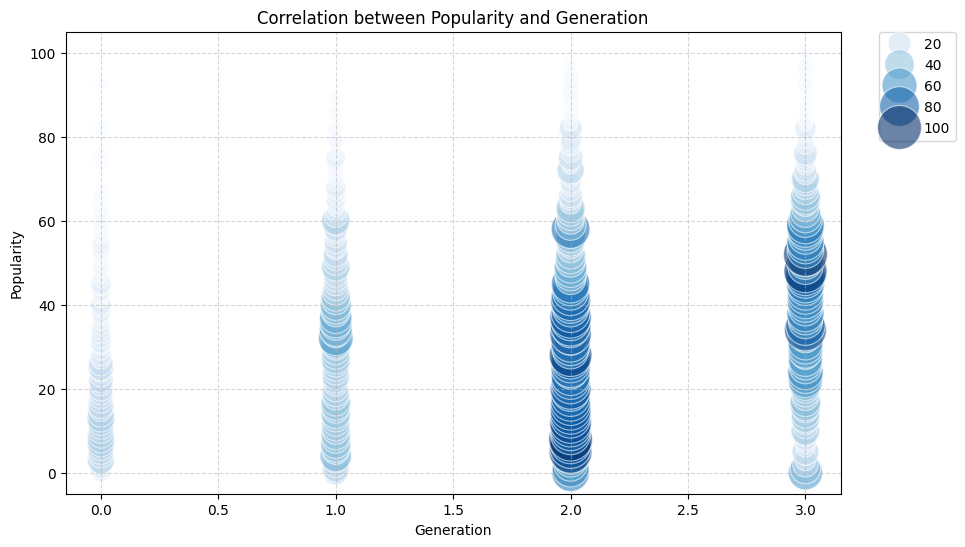

In [86]:
# 1. Prepare the data: Count occurrences for each Popularity-Generation pair
plot_data = df.groupby(['popularity', 'artist_generation_encoded']).size().reset_index(name='Count')

# 2. Create the Scatterplot (Bubble Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x='artist_generation_encoded',
    y='popularity',
    size='Count',
    sizes=(100, 1000),
    alpha=0.6,
    hue='Count',
    palette='Blues'
)

# 3. Formatting
plt.title("Correlation between Popularity and Generation")
plt.xlabel("Generation")
plt.ylabel("Popularity")

# FIXED: Use loc='upper left' or loc=2 (integer), not loc='2' (string)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

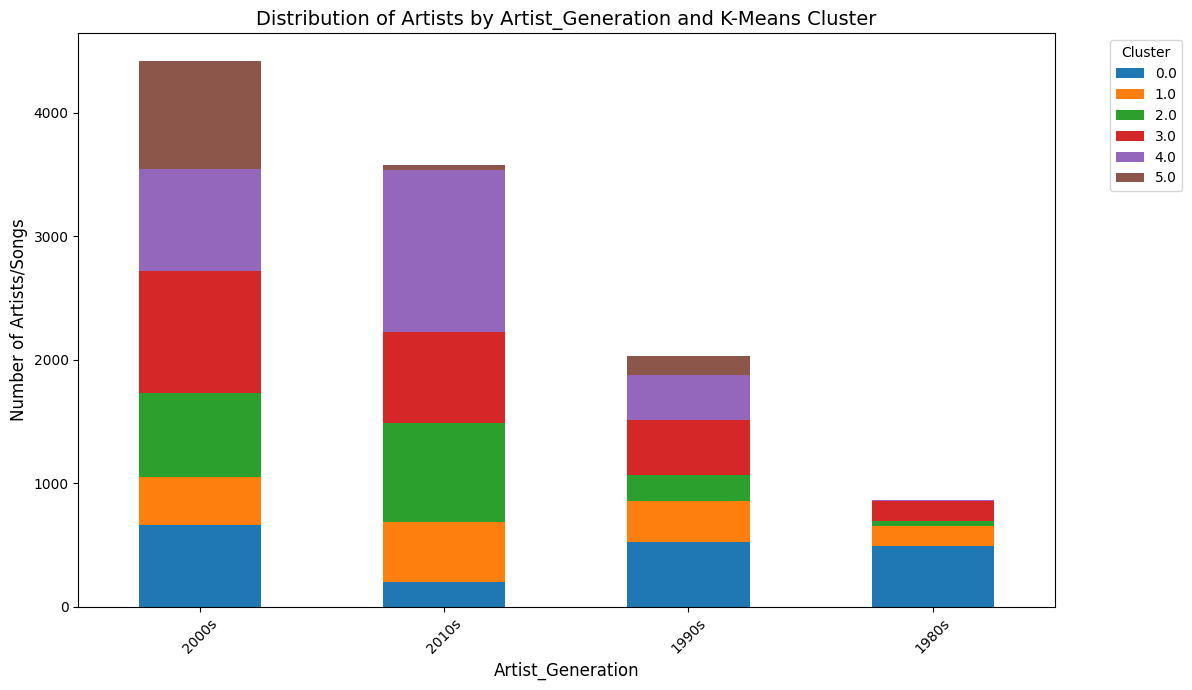

In [87]:
# 1. Create a cross-tabulation of the two features
# This creates a DataFrame where rows are macro_regions and columns are Clusters
cluster_distribution = pd.crosstab(df['Artist_Generation'], df['Cluster'])

# 2. Sort the data by total count (optional, but makes the plot cleaner)
# This mimics your example image where the largest regions are on the left
cluster_distribution['Total'] = cluster_distribution.sum(axis=1)
cluster_distribution = cluster_distribution.sort_values(by='Total', ascending=False).drop(columns='Total')

# Create the plot
ax = cluster_distribution.plot(kind='bar',
                               stacked=True,
                               figsize=(12, 7)) # Colors matching your example

# Customizing the labels and title
plt.title('Distribution of Artists by Artist_Generation and K-Means Cluster', fontsize=14)
plt.xlabel('Artist_Generation', fontsize=12)
plt.ylabel('Number of Artists/Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate names for better readability
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [88]:
# Pass a list of prefixes matching the columns list
df_encoded = pd.get_dummies(
    df,
    columns=['gender', 'has_featured_artist', 'primary_topic', 'Cluster'],
    prefix=['gender', 'has_featured_artist', 'primary_topic', 'Cluster'],  # <--- Must be a list ['a', 'b']
    drop_first=True  # Recommended to prevent multicollinearity
)

In [89]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11166 entries, TR934808 to TR552777
Data columns (total 81 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   id_artist                             11166 non-null  category      
 1   name_artist                           11166 non-null  string        
 2   title                                 11166 non-null  string        
 3   featured_artists                      11166 non-null  object        
 4   language                              11032 non-null  category      
 5   swear_IT                              11166 non-null  int64         
 6   swear_EN                              11166 non-null  int64         
 7   swear_IT_words                        11166 non-null  object        
 8   swear_EN_words                        11166 non-null  object        
 9   n_sentences                           10959 non-null  Int64        

In [90]:
# 2. Define Feature Lists
NUMERIC_FEATURES = [
    'bpm',
    'centroid',
    'rolloff',
    'flux',
    'rms',
    'flatness',
    'spectral_complexity',
    'pitch',
    'duration_ms',
    'popularity',
    'Swear_Rate',
    'n_sentences',
    'tokens_per_sent',
    'char_per_tok',
    'lexical_density',
    'score_love',
    'score_crime',
    'score_drugs',
    'score_politics',
    'score_sadness',
    'score_sex',
    'entropy_lyrics',
    # 'Artist_Release_Entropy',
    # 'Centroid_Entropy',
    'Characters_Per_Minute',
    # 'mean_duration_song_per_album',
    'avg_token_per_clause'
]

CATEGORICAL_FEATURES = [
    'gender_M',
    # 'artist_generation_encoded',
    'has_featured_artist_True',
    # 'primary_topic_Drugs and Alcohol',
    # 'primary_topic_Love and Relationships',
    # 'primary_topic_Money and Success',
    # 'primary_topic_Politics and Society',
    # 'primary_topic_Sadness and Depression',
    # 'primary_topic_Sex',
    # 'primary_topic_Too Short',
    'Cluster_1.0',
    'Cluster_2.0',
    'Cluster_3.0',
    'Cluster_4.0',
    'Cluster_5.0'
]

In [91]:
COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df_encoded[COLS].copy()
y = df_encoded['artist_generation_encoded'].copy()

data_combined = pd.concat([X, y], axis=1)

# --- 2. Define the Columns Used for Transformations (The source of your previous .dropna()) ---
# These are the columns where missing values were removed when you created X_preprocessed:
# Plus any other numeric features that were included in X but not in the log lists
# e.g., features where you ran an Imputer on later.

# --- 3. Filter the combined data based on missing values in the critical columns ---
# This replicates the effect of your previous X.copy().dropna()
data_aligned = data_combined.dropna(subset=COLS)

# --- 4. Separate X and y after alignment ---
X = data_aligned.drop(columns=['artist_generation_encoded'])
y = data_aligned['artist_generation_encoded']

# 4. Target Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASS_NAMES = le.classes_

In [92]:
X_preprocessed = X.copy().dropna()

In [93]:
LOG_TRANSFORM_COLS = [
    'swear_IT',
    'swear_EN',
    'tokens_per_sent',
    'char_per_tok',
    'avg_token_per_clause',
    'duration_ms',
    'Characters_Per_Minute',
    'Swear_Rate',
    'mean_duration_song_per_album'
]
X_preprocessed = X.copy().dropna()

# 1. Apply the log(x+1) transformation using numpy.log1p
for col in LOG_TRANSFORM_COLS:
    # Ensure the column exists in the data subset before transforming
    if col in X_preprocessed.columns:
        # np.log1p(x) calculates log(x + 1)
        X_preprocessed[col] = np.log1p(X_preprocessed[col])

print("✅ Log Transformation applied to selected features in 'X_preprocessed'.")

✅ Log Transformation applied to selected features in 'X_preprocessed'.


In [94]:
# Define the columns that require the reflected log transform
REFLECTED_LOG_TRANSFORM_COLS = [
    'Artist_Release_Entropy',  # Replace with your actual column names
    'entropy_lyrics',
    'Centroid_Entropy',
    'flatness'
]

for col in REFLECTED_LOG_TRANSFORM_COLS:

    if col in X_preprocessed.columns:

        # 1. Calculate the maximum value of the column (max(x))
        max_val = X_preprocessed[col].max()

        # 2. Define the shift constant C = max(x) + delta
        # Using C = max_val + 1 guarantees (C - x) > 0 for all values.
        C = max_val + 1

        # 3. Apply the reflection (C - x) and then the natural logarithm (np.log)
        X_preprocessed[col] = np.log(C - X_preprocessed[col])

print("✅ Reflected Log Transformation (log(C - x)) applied to features with negative skew.")
print(f"Values were reflected using C = max(x) + 1.")

✅ Reflected Log Transformation (log(C - x)) applied to features with negative skew.
Values were reflected using C = max(x) + 1.


In [95]:
# Convert the OHE DataFrame to a NumPy array for stacking
X_categorical_array = X_preprocessed[CATEGORICAL_FEATURES].values

# --- 2. Scale Numeric Features ---
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_preprocessed[NUMERIC_FEATURES].values)

# --- 3. Combine/Stack the Data Horizontally ---
# Use numpy.hstack to combine the scaled numeric features with the encoded categorical features
X_final_preprocessed = np.hstack([
    X_numeric_scaled,
    X_categorical_array
])

# Remove the extra list bracket you had in the original error
X_preprocessed_scaled = X_final_preprocessed

print("✅ Data successfully combined into a single NumPy array for modeling.")
print(f"Final shape of X for modeling: {X_preprocessed_scaled.shape}")

✅ Data successfully combined into a single NumPy array for modeling.
Final shape of X for modeling: (10892, 31)


# 3. Data Splitting Strategy (Unified Train/Val/Test)
To ensure a rigorous and unbiased evaluation, we implement a **three-way split**:

1.  **Test Set (15%)**: Strictly held out for the final performance check. The model will NOT see this data during training or tuning.
2.  **Validation Set (~15% of total)**: Used specifically for hyperparameter tuning. We use `PredefinedSplit` to tell `GridSearchCV` to validate strictly on this subset.
3.  **Training Set (Remaining ~70%)**: Used to fit the models during the Grid Search process.

This approach avoids data leakage and ensures that our hyperparameters are tuned on a validation set that is distinct from the final test set.



In [96]:
# 1. First Split: Separate out the Test set (e.g., 15% held out)
# We split X and y into temporary train (85%) and final test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_preprocessed_scaled, y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

# 2. Second Split: Separate Train and Validation sets from the temporary train set
# We want the Validation set to be roughly 15% of the TOTAL data.
# Since X_temp is 85% of total, we need (15/85) approx 0.176 of X_temp to be validation.
val_size_relative = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_relative,
    random_state=42,
    stratify=y_temp
)

# 3. Prepare PredefinedSplit for GridSearchCV
# The 'split_index' array tells GridSearchCV which fold each sample belongs to.
# -1: Training sample (always used for training in the validation loop)
#  0: Validation sample (used for evaluation)
# We must concatenate X_train and X_val to give GridSearchCV a single 'X' matrix,
# but the split_index will enforce the fixed train/val separation.

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

# --- Compute Sample Weights ---
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_val)
print(f'   - Sample Weights Computed: {len(sample_weights)}')

# Combine for GridSearch fitting (order matters: train first, then val)
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

print("✅ Data Split Completed Successfully")
print(f"   - Training Set Size:   {X_train.shape[0]} (Used for model fitting)")
print(f"   - Validation Set Size: {X_val.shape[0]} (Used for hyperparameter tuning)")
print(f"   - Test Set Size:       {X_test.shape[0]} (Held out for final evaluation)")
print(f"   - PredefinedSplit:     Ready with {len(split_index)} indices.")



   - Sample Weights Computed: 9258
✅ Data Split Completed Successfully
   - Training Set Size:   7624 (Used for model fitting)
   - Validation Set Size: 1634 (Used for hyperparameter tuning)
   - Test Set Size:       1634 (Held out for final evaluation)
   - PredefinedSplit:     Ready with 9258 indices.


## 4.2 K-Nearest Neighbors (KNN)
 KNN classifies samples based on the majority class of their neighbors.
 **Hyperparameters tuned:**
 *   `n_neighbors`: The 'k' in KNN. critical for bias-variance tradeoff.
 *   `weights`: 'uniform' treats all neighbors equally; 'distance' gives more weight to closer ones.
 *   `metric`: Distance measure (Euclidean vs Manhattan).


--- Starting Grid Search for KNN ---
Fitting 1 folds for each of 120 candidates, totalling 120 fits
✅ Best Parameters: {'metric': 'manhattan', 'n_neighbors': 29, 'weights': 'uniform'}
✅ Best CV F1 Score: 0.5098

🔎 Evaluating KNN on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.26      0.37       130
           1       0.57      0.28      0.38       304
           2       0.55      0.71      0.62       664
           3       0.61      0.65      0.63       536

    accuracy                           0.58      1634
   macro avg       0.60      0.48      0.50      1634
weighted avg       0.58      0.58      0.56      1634

Confusion Matrix:


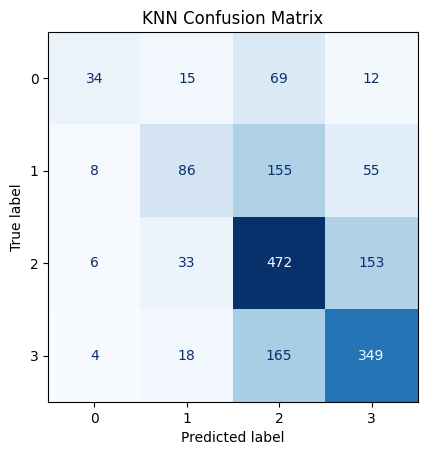


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


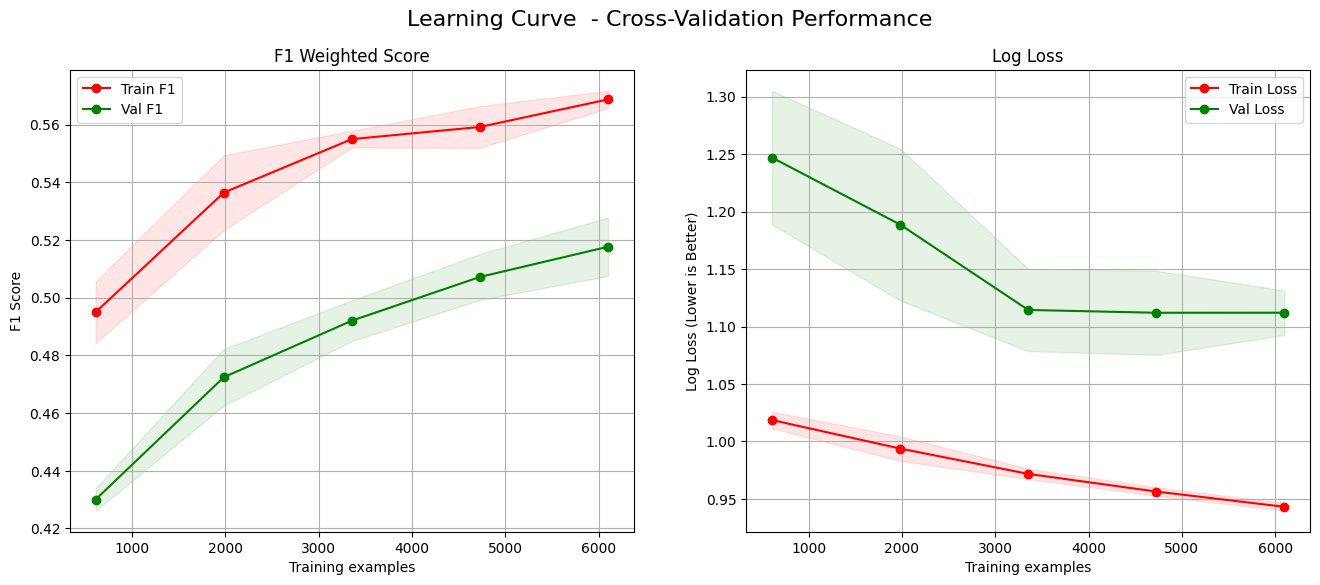


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


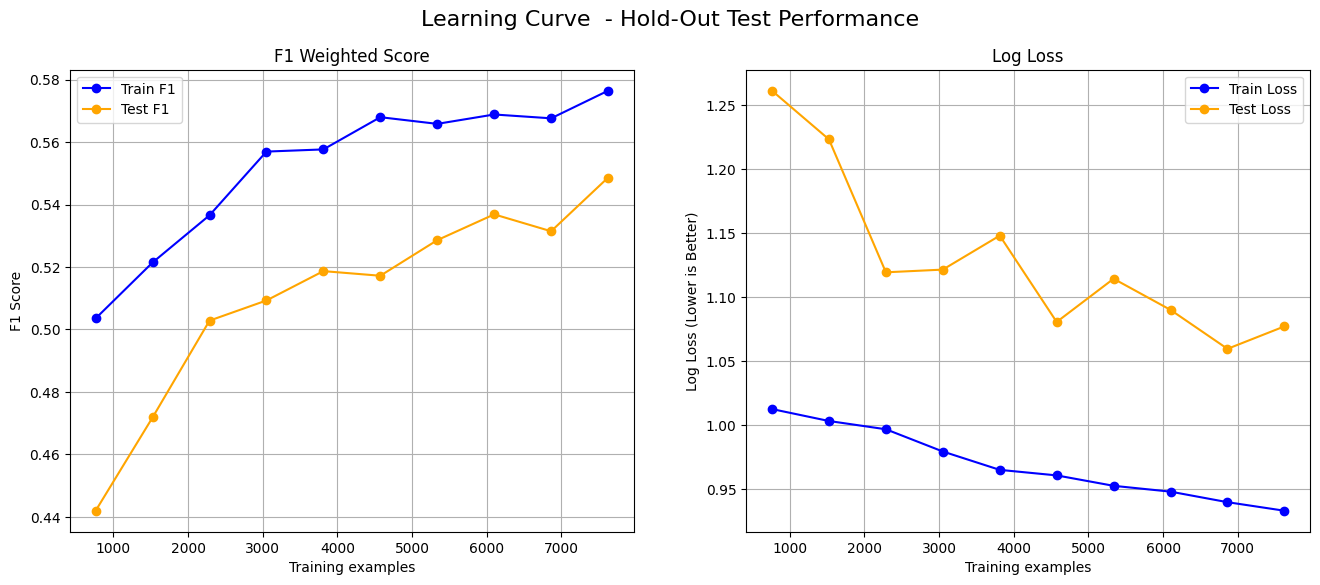

In [97]:
# --- KNN Grid Search ---
param_grid_knn = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for KNN ---")
grid_knn.fit(X_train_val, y_train_val)

print(f"✅ Best Parameters: {grid_knn.best_params_}")
print(f"✅ Best CV F1 Score: {grid_knn.cv_results_['mean_test_f1'][grid_knn.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating KNN on Hold-Out Test Set...")
best_model_grid_knn = grid_knn.best_estimator_
y_pred_grid_knn = best_model_grid_knn.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_knn))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"KNN Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_knn, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_knn, "Learning Curve ", X_train, y_train, X_test, y_test)




## 4.3 Gaussian Naive Bayes
 A probabilistic classifier based on Bayes' theorem.
 **Hyperparameters tuned:**
 *   `var_smoothing`: Adds stability to calculation, effectively smoothing the curve.


--- Starting Grid Search for Naive Bayes ---
Fitting 1 folds for each of 100 candidates, totalling 100 fits
✅ Best Parameters: {'var_smoothing': np.float64(0.0657933224657568)}
✅ Best CV F1 Score: 0.4770

🔎 Evaluating Naive Bayes on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.77      0.31       130
           1       0.43      0.24      0.31       304
           2       0.62      0.36      0.45       664
           3       0.59      0.63      0.61       536

    accuracy                           0.46      1634
   macro avg       0.46      0.50      0.42      1634
weighted avg       0.54      0.46      0.46      1634

Confusion Matrix:


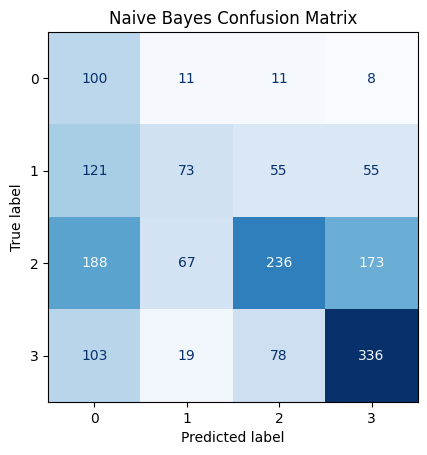


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


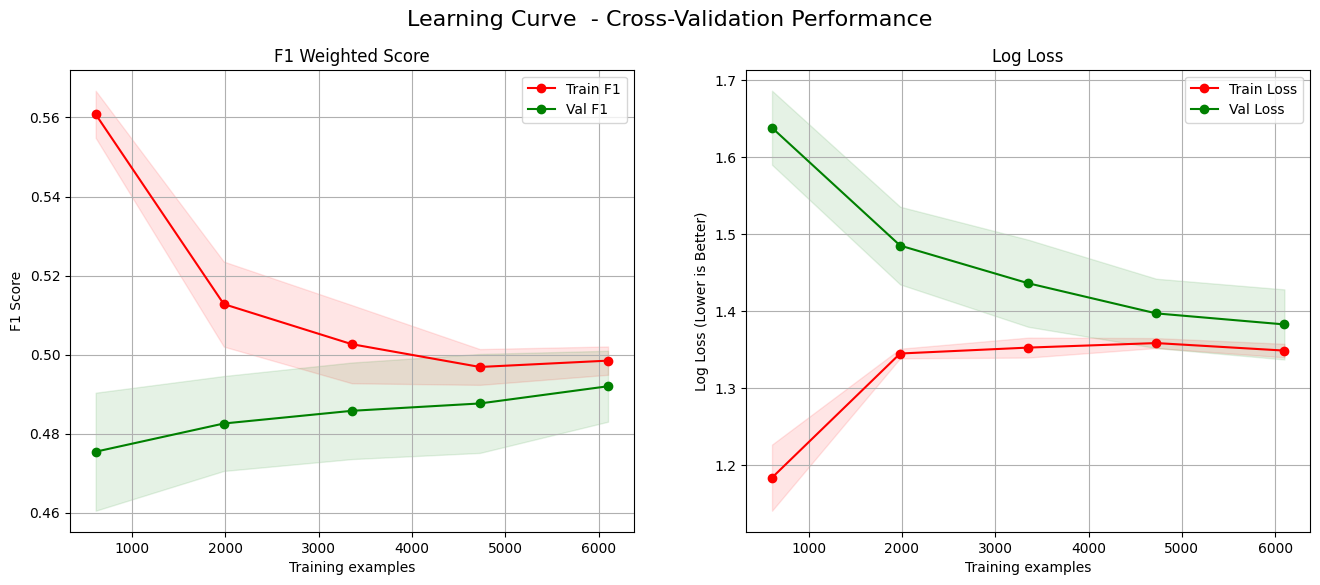


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


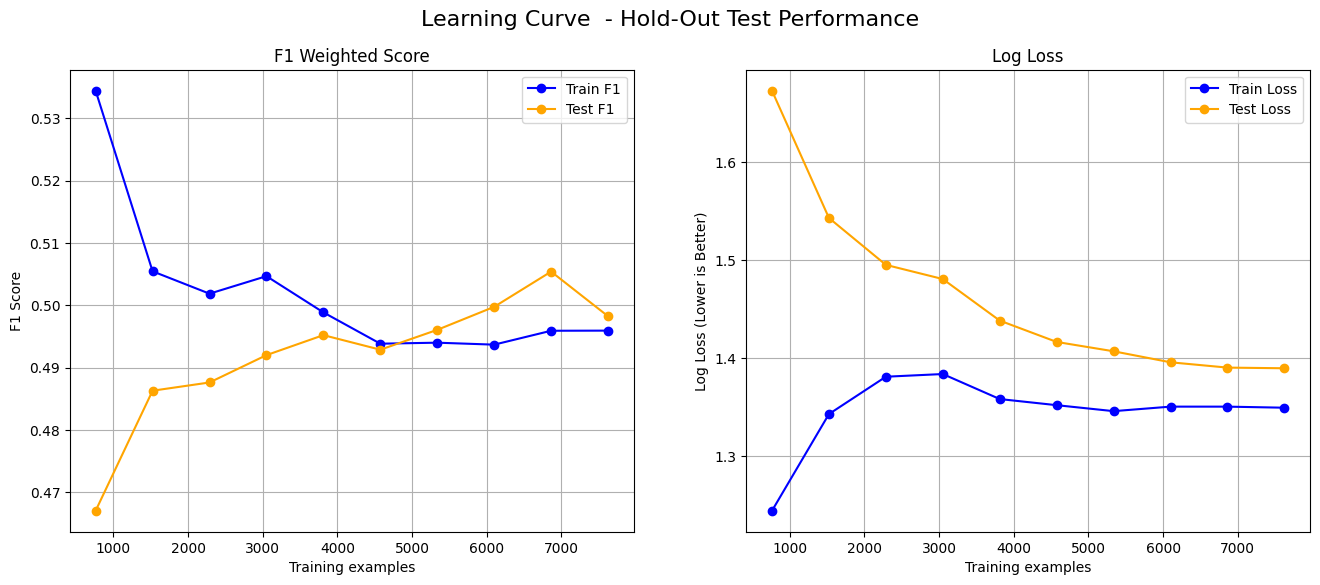

In [98]:
# --- Naive Bayes Grid Search ---
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for Naive Bayes ---")
grid_nb.fit(X_train_val, y_train_val, sample_weight=sample_weights)

print(f"✅ Best Parameters: {grid_nb.best_params_}")
print(f"✅ Best CV F1 Score: {grid_nb.cv_results_['mean_test_f1'][grid_nb.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating Naive Bayes on Hold-Out Test Set...")
best_model_grid_nb = grid_nb.best_estimator_
y_pred_grid_nb = best_model_grid_nb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_nb))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Naive Bayes Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_nb, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_nb, "Learning Curve ", X_train, y_train, X_test, y_test)




## 4.4 Random Forest
 An ensemble of Decision Trees. Robust against overfitting.
 **Hyperparameters tuned:**
 *   `n_estimators`: Number of trees.
 *   `max_depth`: Depth of individual trees.
 *   `bootstrap`: Whether to use bootstrap samples.


--- Starting Grid Search for Random Forest ---
Fitting 1 folds for each of 16 candidates, totalling 16 fits
⚠️ Warning: All models exceeded loss gap threshold. Picking best F1 regardless.
✅ Best Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
✅ Best CV F1 Score: 0.5553

🔎 Evaluating Random Forest on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.46      0.47       130
           1       0.50      0.42      0.46       304
           2       0.63      0.55      0.59       664
           3       0.60      0.75      0.67       536

    accuracy                           0.58      1634
   macro avg       0.55      0.55      0.54      1634
weighted avg       0.58      0.58      0.58      1634

Confusion Matrix:


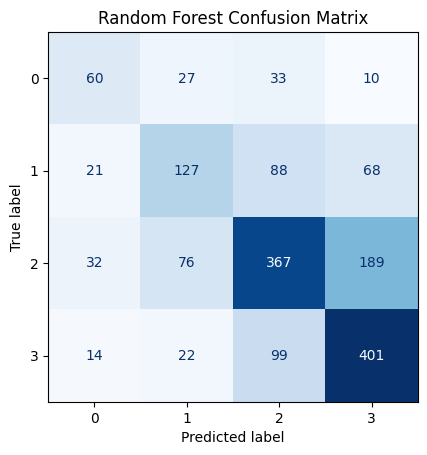


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


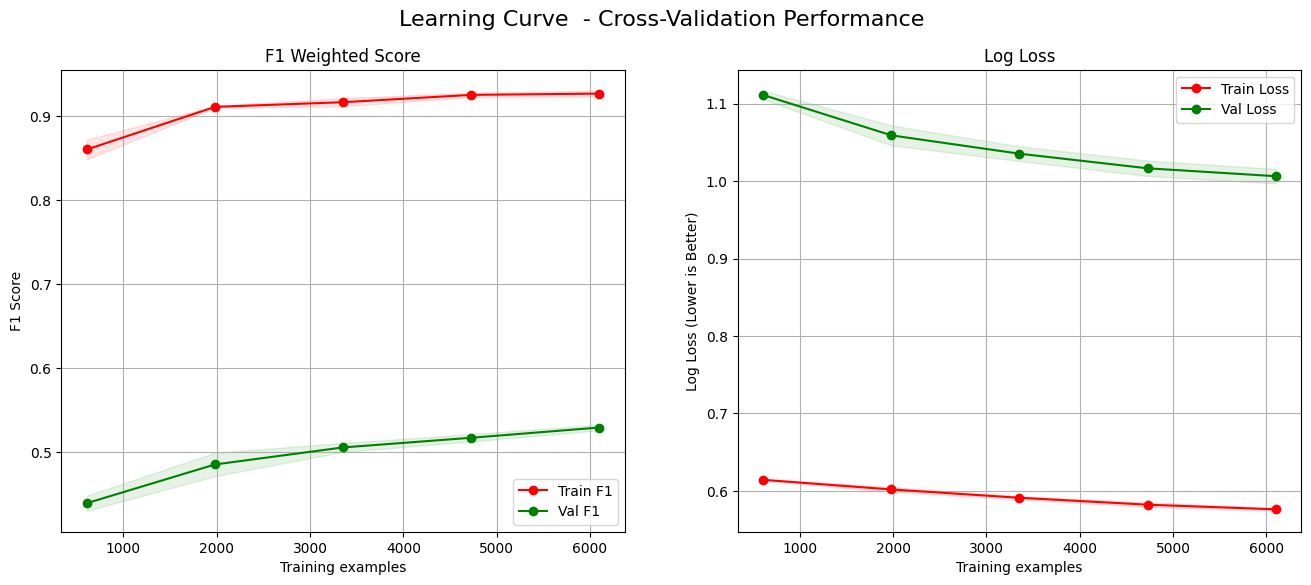


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


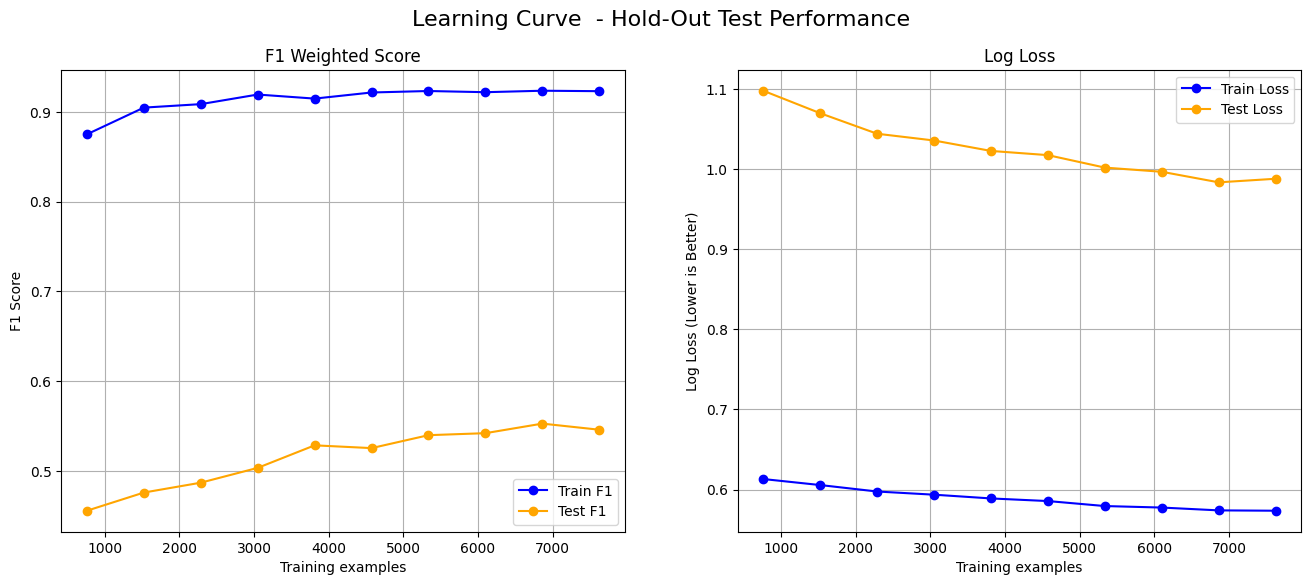

In [99]:
# --- Random Forest Grid Search ---
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'bootstrap': [True]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for Random Forest ---")
grid_rf.fit(X_train_val, y_train_val, sample_weight=sample_weights)

print(f"✅ Best Parameters: {grid_rf.best_params_}")
print(f"✅ Best CV F1 Score: {grid_rf.cv_results_['mean_test_f1'][grid_rf.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating Random Forest on Hold-Out Test Set...")
best_model_grid_rf = grid_rf.best_estimator_
y_pred_grid_rf = best_model_grid_rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_rf))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Random Forest Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_rf, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_rf, "Learning Curve ", X_train, y_train, X_test, y_test)




## 4.0 Logistic Regression
A baseline linear model. Good for understanding feature importance and linear relationships.
**Hyperparameters tuned:**
*   `C`: Inverse of regularization strength (smaller = stronger regularization).
*   `penalty`: Regularization type (l1, l2).
*   `solver`: Algorithm to use in the optimization problem.


--- Starting Grid Search for Logistic Regression ---
Fitting 1 folds for each of 12 candidates, totalling 12 fits


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. A

✅ Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Best CV F1 Score: 0.5414

🔎 Evaluating Logistic Regression on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.74      0.37       130
           1       0.39      0.34      0.36       304
           2       0.64      0.34      0.44       664
           3       0.60      0.70      0.65       536

    accuracy                           0.49      1634
   macro avg       0.47      0.53      0.46      1634
weighted avg       0.55      0.49      0.49      1634

Confusion Matrix:


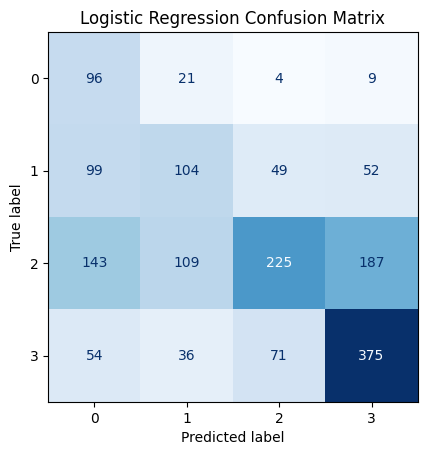


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


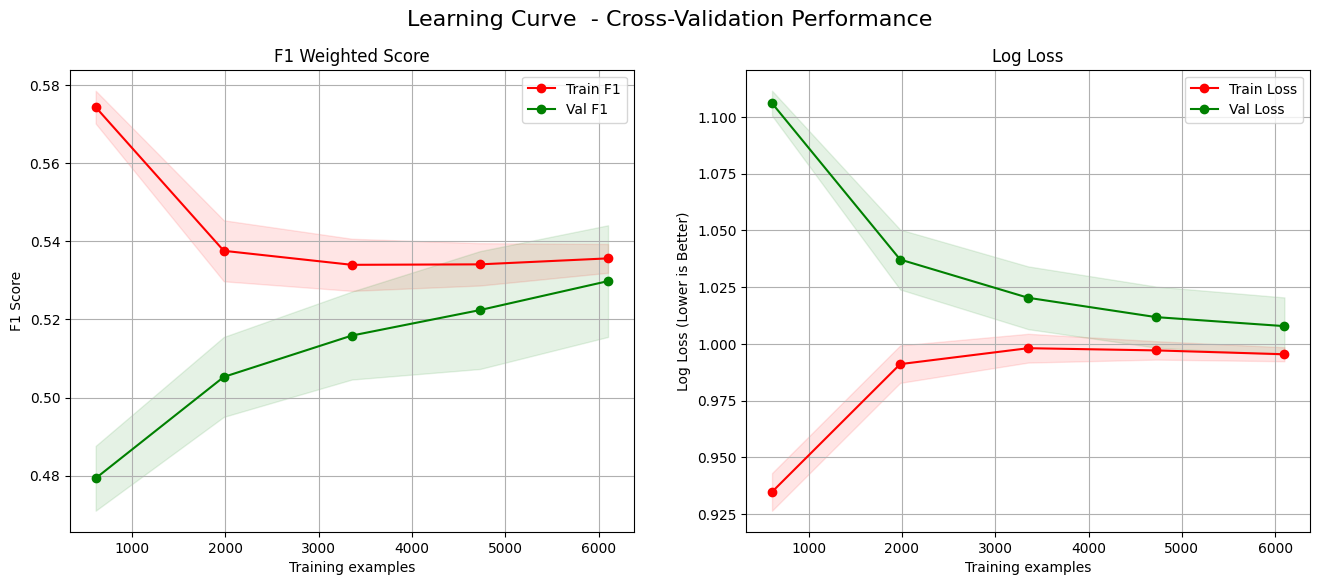


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


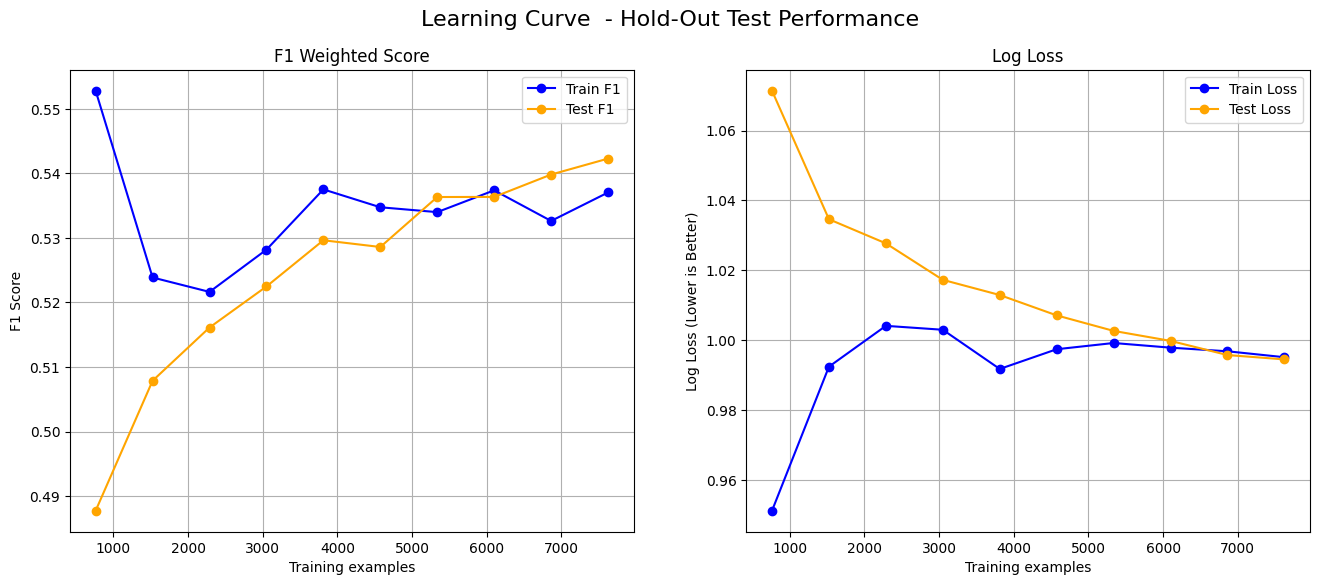

In [100]:
from sklearn.linear_model import LogisticRegression

# --- Logistic Regression Grid Search ---
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'], # lbfgs supports l2
    'solver': ['lbfgs', 'liblinear']
}

# Add l1 for liblinear
# Ideally we could do a list of dicts for param_grid, but let's keep it simple.
# We will use a simpler grid compatible with defaults or just stick to l2 for robust baseline.
# Let's use a robust grid:
param_grid_lr = [
    {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10]},
    {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10]}
]

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for Logistic Regression ---")
grid_lr.fit(X_train_val, y_train_val, sample_weight=sample_weights)

print(f"✅ Best Parameters: {grid_lr.best_params_}")
print(f"✅ Best CV F1 Score: {grid_lr.cv_results_['mean_test_f1'][grid_lr.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating Logistic Regression on Hold-Out Test Set...")
best_model_grid_lr = grid_lr.best_estimator_
y_pred_grid_lr = best_model_grid_lr.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_lr))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Logistic Regression Confusion Matrix")
plt.show()

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_lr, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_lr, "Learning Curve ", X_train, y_train, X_test, y_test)


## 4.1 Decision Tree Classifier
 We start with a Decision Tree, a simple yet interpretable model.
 **Hyperparameters tuned:**
 *   `criterion`: Measures the quality of a split (Gini vs Entropy).
 *   `max_depth`: Controls tree complexity to prevent overfitting.
 *   `min_samples_split/leaf`: Further constraints on tree growth.


--- Starting Grid Search for Decision Tree ---
Fitting 1 folds for each of 90 candidates, totalling 90 fits


⚠️ Warning: All models exceeded loss gap threshold. Picking best F1 regardless.
✅ Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
✅ Best CV F1 Score: 0.5163

🔎 Evaluating Decision Tree on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.62      0.38       130
           1       0.36      0.48      0.41       304
           2       0.63      0.38      0.48       664
           3       0.60      0.61      0.61       536

    accuracy                           0.49      1634
   macro avg       0.47      0.52      0.47      1634
weighted avg       0.54      0.49      0.50      1634

Confusion Matrix:


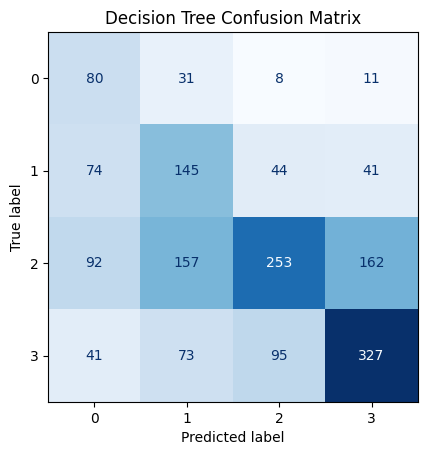


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


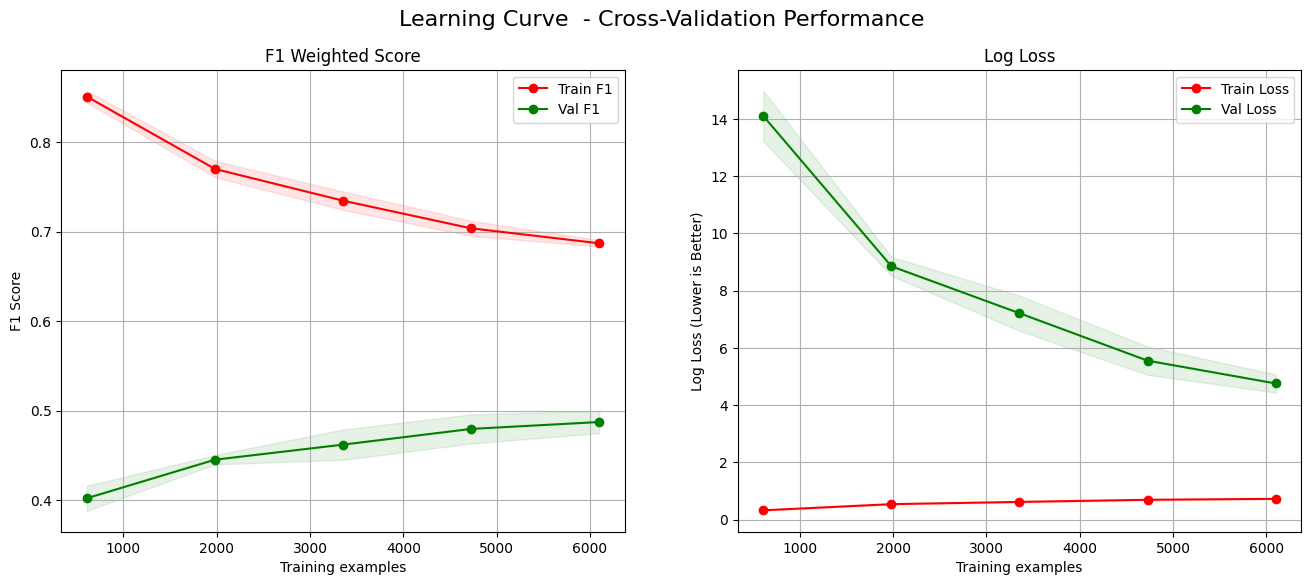


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


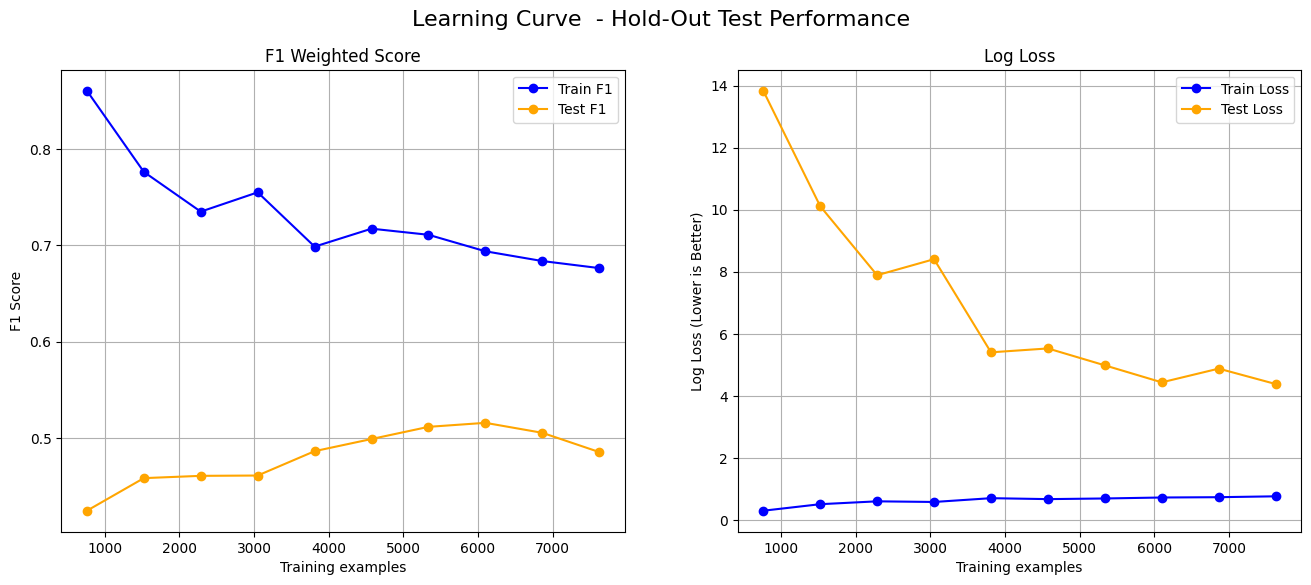

In [101]:
# --- Decision Tree Grid Search ---
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for Decision Tree ---")
grid_dt.fit(X_train_val, y_train_val, sample_weight=sample_weights)

print(f"✅ Best Parameters: {grid_dt.best_params_}")
print(f"✅ Best CV F1 Score: {grid_dt.cv_results_['mean_test_f1'][grid_dt.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating Decision Tree on Hold-Out Test Set...")
best_model_grid_dt = grid_dt.best_estimator_
y_pred_grid_dt = best_model_grid_dt.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_dt))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Decision Tree Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_dt, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_dt, "Learning Curve ", X_train, y_train, X_test, y_test)




## 4.6 XGBoost (Extreme Gradient Boosting)
 An optimized implementation of gradient boosting, known for speed and performance.
 **Hyperparameters tuned:**
 *   `colsample_bytree`: Subsample ratio of columns when constructing each tree.
 *   `learning_rate`, `max_depth`, `n_estimators`: Standard boosting parameters.


--- Starting Grid Search for XGBoost ---
Fitting 1 folds for each of 72 candidates, totalling 72 fits


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

✅ Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
✅ Best CV F1 Score: 0.5817

🔎 Evaluating XGBoost on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.71      0.43       130
           1       0.46      0.49      0.47       304
           2       0.70      0.40      0.51       664
           3       0.62      0.73      0.67       536

    accuracy                           0.55      1634
   macro avg       0.52      0.58      0.52      1634
weighted avg       0.60      0.55      0.55      1634

Confusion Matrix:


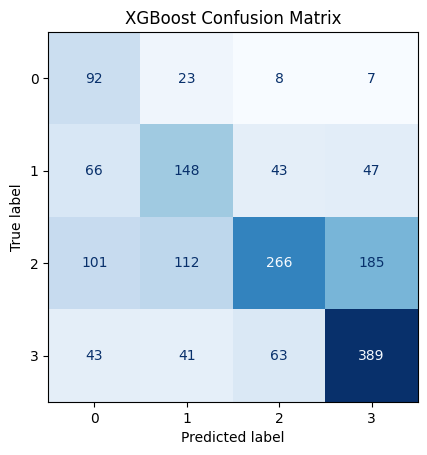


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:50:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:50:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:50:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:50:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

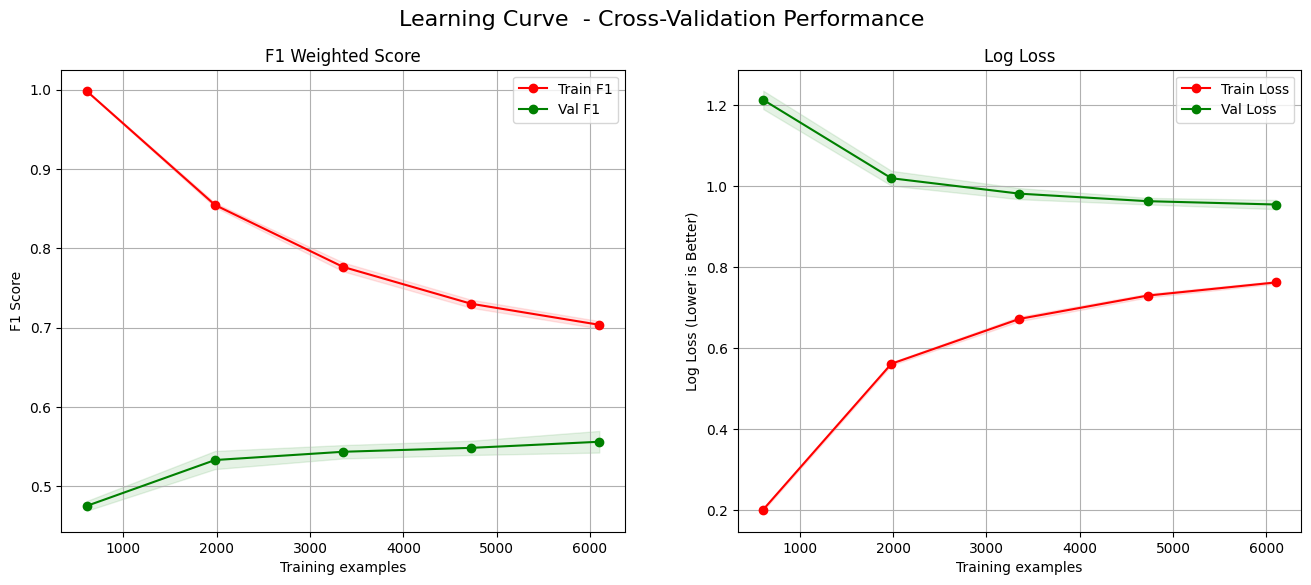


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:51:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:51:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:51:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:51:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

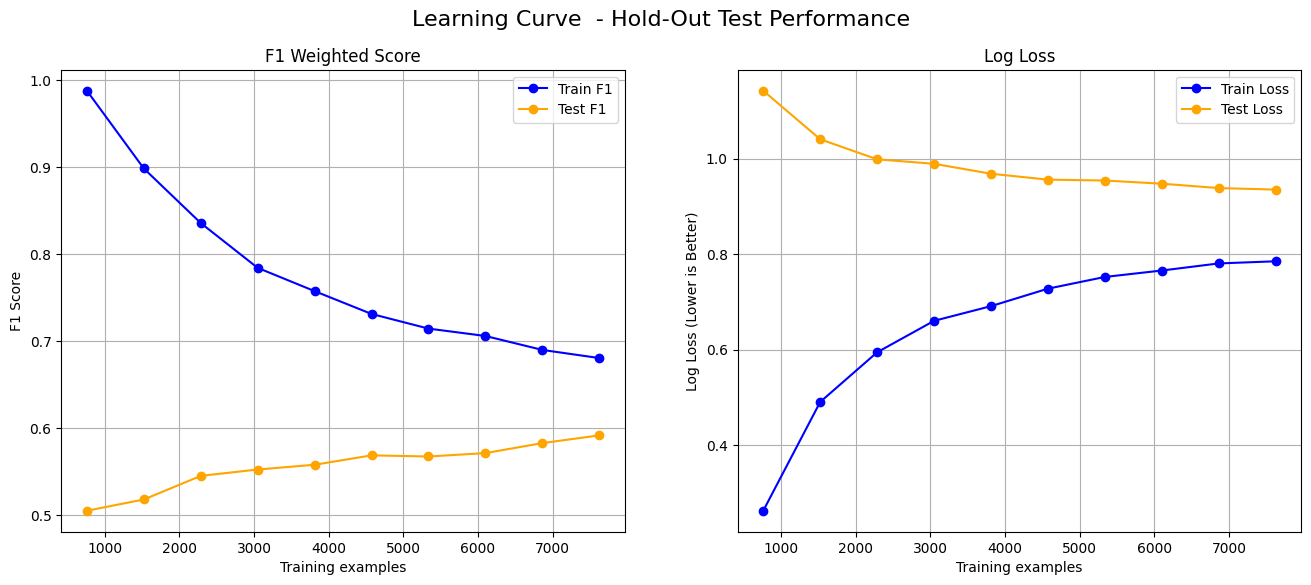


📈 Generating XGBoost Training History Plot...


/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [10:51:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


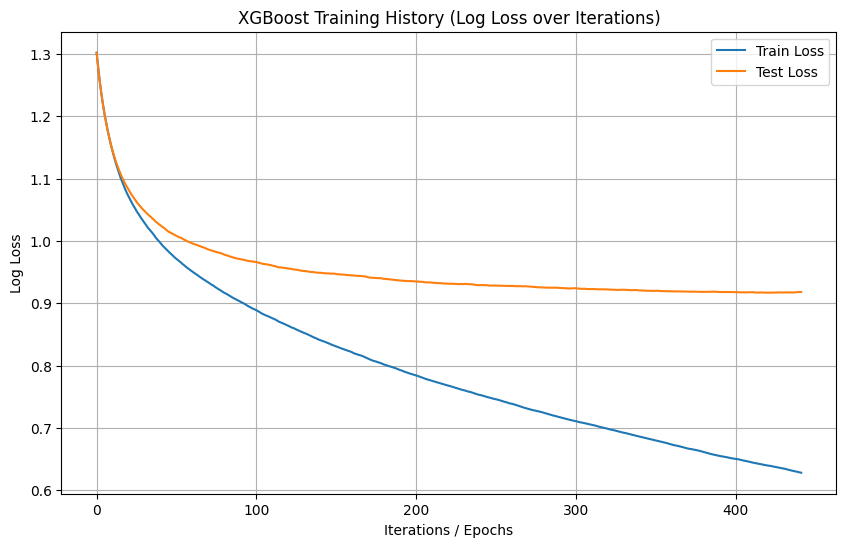

In [102]:
# --- XGBoost Grid Search ---
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(tree_method='hist', device='cuda', use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid=param_grid_xgb,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for XGBoost ---")
grid_xgb.fit(X_train_val, y_train_val, sample_weight=sample_weights)

print(f"✅ Best Parameters: {grid_xgb.best_params_}")
print(f"✅ Best CV F1 Score: {grid_xgb.cv_results_['mean_test_f1'][grid_xgb.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating XGBoost on Hold-Out Test Set...")
best_model_grid_xgb = grid_xgb.best_estimator_
y_pred_grid_xgb = best_model_grid_xgb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_xgb))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"XGBoost Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_xgb, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_xgb, "Learning Curve ", X_train, y_train, X_test, y_test)





# --- Iteration History (Log Loss) ---
# To visualize convergence, we retrain the best model parameters with explicit eval_set
print(f"\n📈 Generating XGBoost Training History Plot...")
best_params_xgb = grid_xgb.best_params_
# Remove n_estimators to avoid conflict with explicit value
best_params_xgb = best_params_xgb.copy()
if 'n_estimators' in best_params_xgb:
    del best_params_xgb['n_estimators']
xgb_history_model = xgb.XGBClassifier(
    **best_params_xgb,
    tree_method='hist', device='cuda',
    n_estimators=500, # Ensure enough estimators to see convergence
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=20 # Stop if no improvement
)

xgb_history_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

plot_training_history(xgb_history_model.evals_result(), 'XGBoost', metric='mlogloss')


## 4.7 Multi-Layer Perceptron (Neural Network)
 A feedforward artificial neural network.
 **Hyperparameters tuned:**
 *   `hidden_layer_sizes`: Structure of the network (number of neurons/layers).
 *   `activation`: Activation function (ReLU, Tanh).
 *   `alpha`: L2 penalty (regularization) parameter.


--- Starting Grid Search for MLP ---
Fitting 1 folds for each of 48 candidates, totalling 48 fits
✅ Best Parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
✅ Best CV F1 Score: 0.5592

🔎 Evaluating MLP on Hold-Out Test Set...
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.42      0.47       130
           1       0.56      0.36      0.44       304
           2       0.58      0.65      0.61       664
           3       0.64      0.71      0.67       536

    accuracy                           0.60      1634
   macro avg       0.58      0.53      0.55      1634
weighted avg       0.59      0.60      0.59      1634

Confusion Matrix:


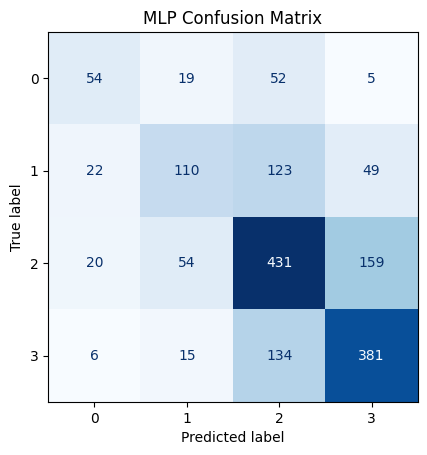


📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...


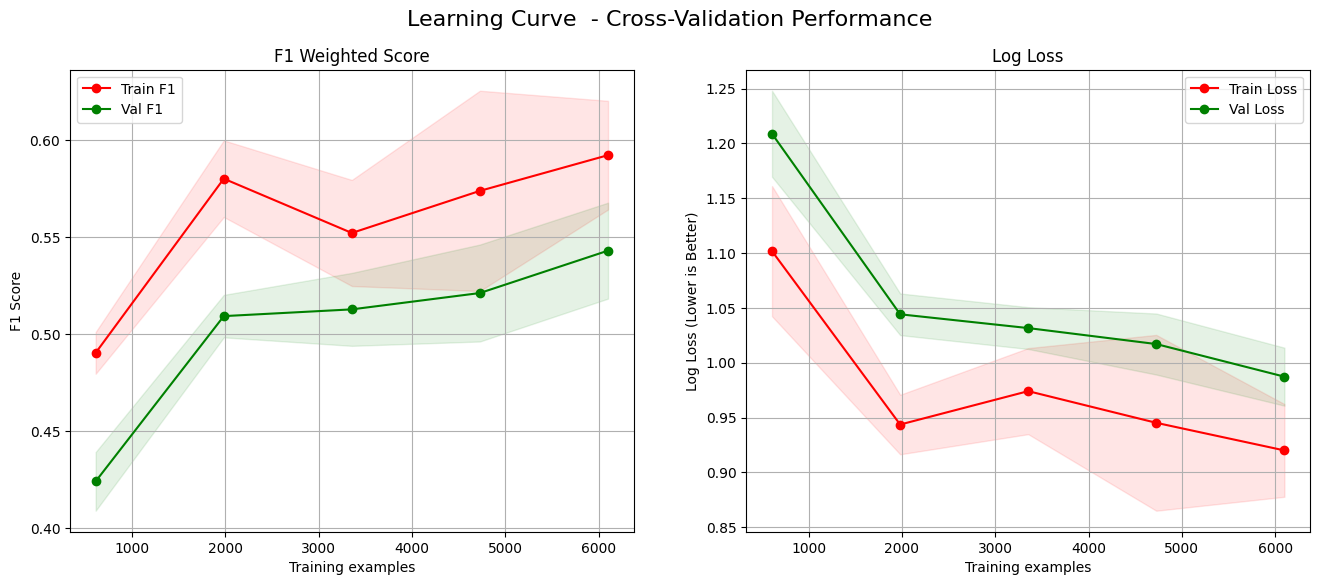


📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...


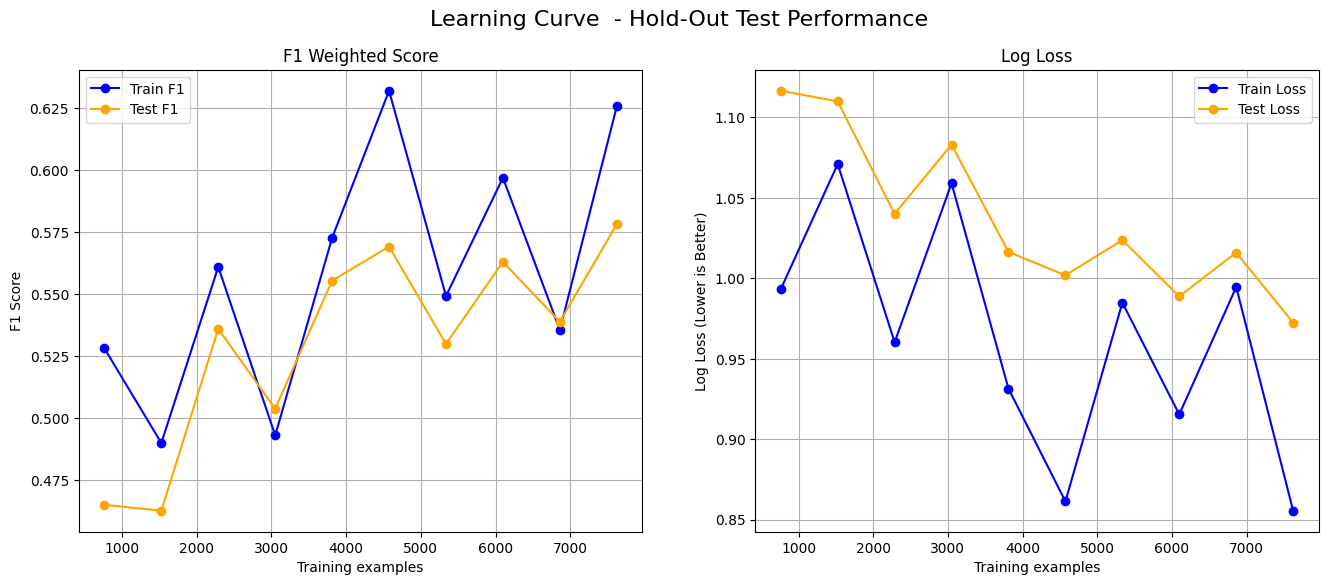


📈 Generating MLP Training History Plot...


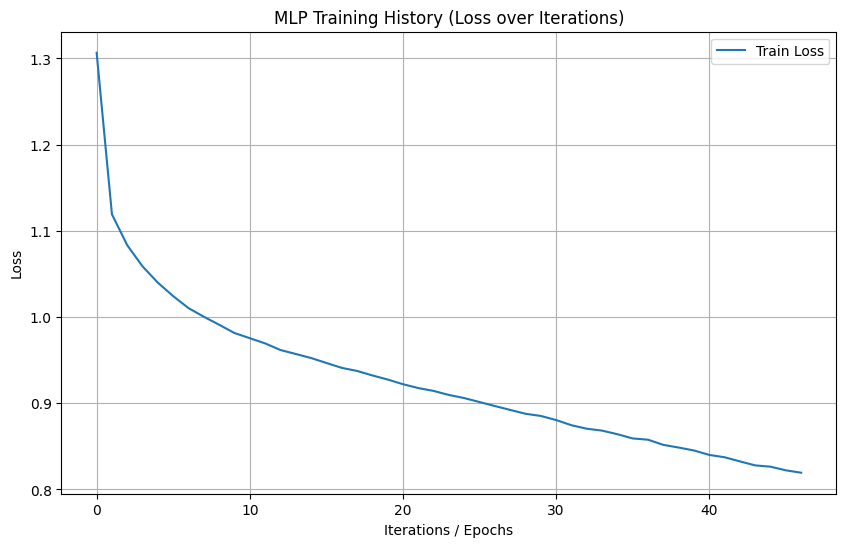

In [103]:
# --- MLP Grid Search ---
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, early_stopping=True, random_state=42),
    param_grid=param_grid_mlp,
    cv=pds,
    scoring={'f1': 'f1_weighted', 'loss': 'neg_log_loss'},
    n_jobs=-1,
    verbose=1,
    refit=select_model_with_gap_check,
    return_train_score=True
)

print("--- Starting Grid Search for MLP ---")
grid_mlp.fit(X_train_val, y_train_val)

print(f"✅ Best Parameters: {grid_mlp.best_params_}")
print(f"✅ Best CV F1 Score: {grid_mlp.cv_results_['mean_test_f1'][grid_mlp.best_index_]:.4f}")

# --- Evaluation on Held-Out Test Set ---
print(f"\n🔎 Evaluating MLP on Hold-Out Test Set...")
best_model_grid_mlp = grid_mlp.best_estimator_
y_pred_grid_mlp = best_model_grid_mlp.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_grid_mlp))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_grid_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"MLP Confusion Matrix")
plt.show()

# --- Learning Curve (Loss Curve Check) ---
# We use X_train_val because we want to see how it learns as data grows, 
# fitting on Train and checking on Val (internal SV)

# --- Dual Learning Curves (CV) ---
print(f"\n📊 Plotting Dual Learning Curves (F1 & Loss) for Learning Curve  (CV)...")
plot_dual_learning_curves(best_model_grid_mlp, "Learning Curve ", X_train, y_train, cv=5, n_jobs=-1)

# --- Dual Hold-Out Curves (Test) ---
print(f"\n📉 Plotting Dual Hold-Out Curves (F1 & Loss) for Learning Curve  (Test)...")
plot_dual_holdout_curves(best_model_grid_mlp, "Learning Curve ", X_train, y_train, X_test, y_test)




# --- Iteration History (Loss Curve) ---
print(f"\n📈 Generating MLP Training History Plot...")
# The best_estimator_ from GridSearchCV (refit=True) already has the loss_curve_ populated
plot_training_history(best_model_grid_mlp, 'MLP')


# 5. Final Model Evaluation
 In this final step, we take the **best estimators** identified by GridSearchCV for each model type.
 
 **Critical Step:**
 We retrain these best models on the **combined training and validation sets** to maximize the data they learn from. Then, we evaluate their performance on the **held-out Test Set** which has been untouched until now.
 
 We report:
 *   **Accuracy & F1 Score (Weighted)**
 *   **Classification Reports**
 *   **Confusion Matrices** for the top performing models.



In [104]:
# --- Final Leaderboard with Overfitting Check ---
from sklearn.metrics import f1_score

results_summary = []

model_grids = {
    "Logistic Regression": grid_lr,
    "KNN": grid_knn,
    "Naive Bayes": grid_nb, 
    "Random Forest": grid_rf,
    "Decision Tree": grid_dt,
    "XGBoost": grid_xgb,
    "MLP": grid_mlp
}

print("\n📊 Consolidating Results & Checking for Overfitting...\n")

for name, grid in model_grids.items():
    # Validation Score (from CV)
    val_f1 = grid.cv_results_['mean_test_f1'][grid.best_index_]
    
    # Training Score (Self-Prediction)
    # Note: We use the best estimator on the Training part of X_train_val
    # We kept the original split logic, so X_train and y_train variables should be available.
    best_est = grid.best_estimator_
    y_train_pred = best_est.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    
    # Calculate Gaps
    gap = train_f1 - val_f1
    
    # Overfitting Flag (e.g. if Train is > 10% better than Val)
    # Threshold is purely heuristic, adjustable.
    overfit_warning = "⚠️ High" if gap > 0.10 else "Add. OK"
    
    results_summary.append({
        "Model": name,
        "Train F1": train_f1,
        "Val F1": val_f1,
        "Gap": gap,
        "Overfit Risk": overfit_warning,
        "Estimator": best_est
    })

df_summary = pd.DataFrame(results_summary).sort_values(by="Val F1", ascending=False)

# Display Table
print(df_summary[["Model", "Train F1", "Val F1", "Gap", "Overfit Risk"]])

# --- Smart Selection ---
# Filter out high risk models unless everything is high risk
low_risk_models = df_summary[df_summary["Gap"] <= 0.10]

if not low_risk_models.empty:
    best_row = low_risk_models.iloc[0]
    reason = "Highest Val F1 with Low Overfitting Risk"
else:
    # If all overfit, just take the best val score but warn
    best_row = df_summary.iloc[0]
    reason = "Highest Val F1 (Warning: All models show high overfitting gaps)"

print(f"\n🏆 Selected Best Model: {best_row['Model']}")
print(f"   Reason: {reason}")
print(f"   Validation F1: {best_row['Val F1']:.4f}")
print(f"   Train-Val Gap: {best_row['Gap']:.4f}")

# Optional: You can save this best model for deployment here





📊 Consolidating Results & Checking for Overfitting...

                 Model  Train F1    Val F1       Gap Overfit Risk
5              XGBoost  0.680445  0.581653  0.098793      Add. OK
6                  MLP  0.625546  0.559210  0.066336      Add. OK
3        Random Forest  0.923181  0.555294  0.367887      ⚠️ High
0  Logistic Regression  0.537038  0.541413 -0.004374      Add. OK
4        Decision Tree  0.676374  0.516336  0.160038      ⚠️ High
1                  KNN  0.576453  0.509846  0.066607      Add. OK
2          Naive Bayes  0.495945  0.476977  0.018968      Add. OK

🏆 Selected Best Model: XGBoost
   Reason: Highest Val F1 with Low Overfitting Risk
   Validation F1: 0.5817
   Train-Val Gap: 0.0988


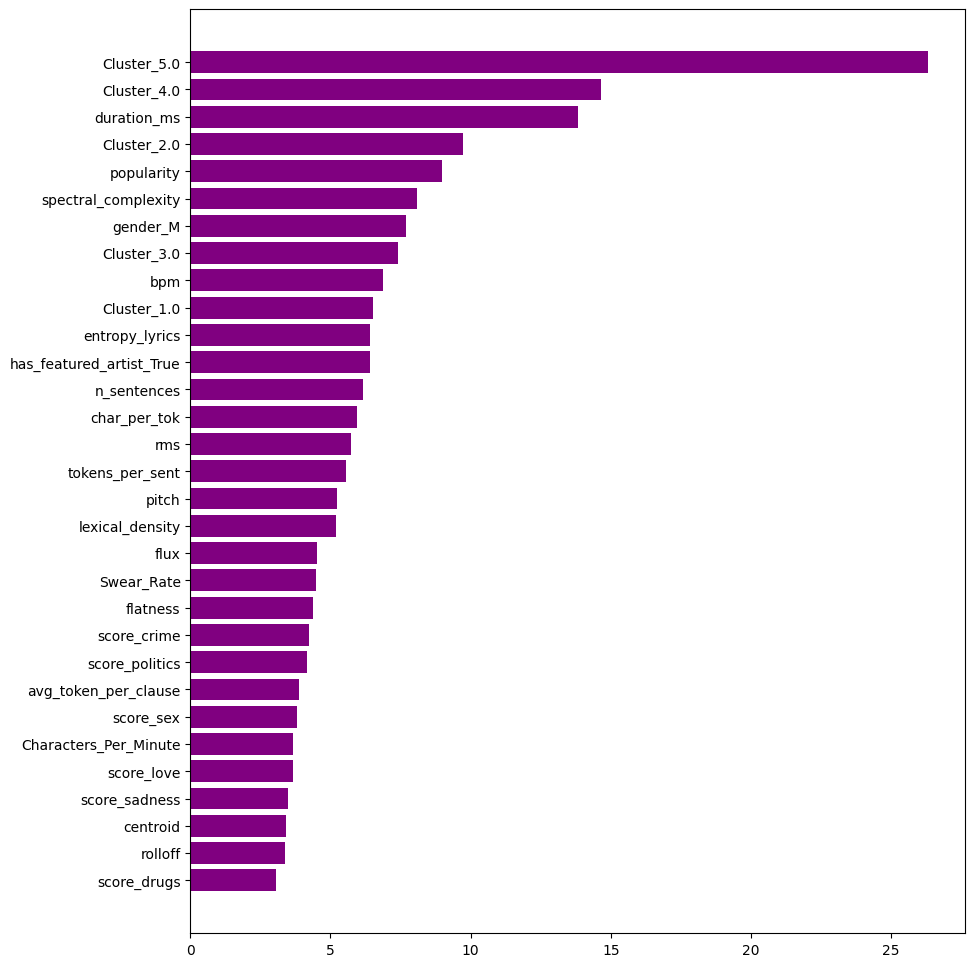

In [106]:
# Get importance dictionary

final_feature_names = COLS

importance_dict = best_model_grid_xgb.get_booster().get_score(importance_type='gain')

# Map generic 'f' names back to your actual names
# XGBoost uses 'f0', 'f1', etc., based on the index in your feature list
named_importance = {final_feature_names[int(k[1:])]: v for k, v in importance_dict.items()}

# Create DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': list(named_importance.keys()),
    'Importance': list(named_importance.values())
}).sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 12))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple')
plt.show()

📊 SHAP Summary Plot (Global Feature Importance)


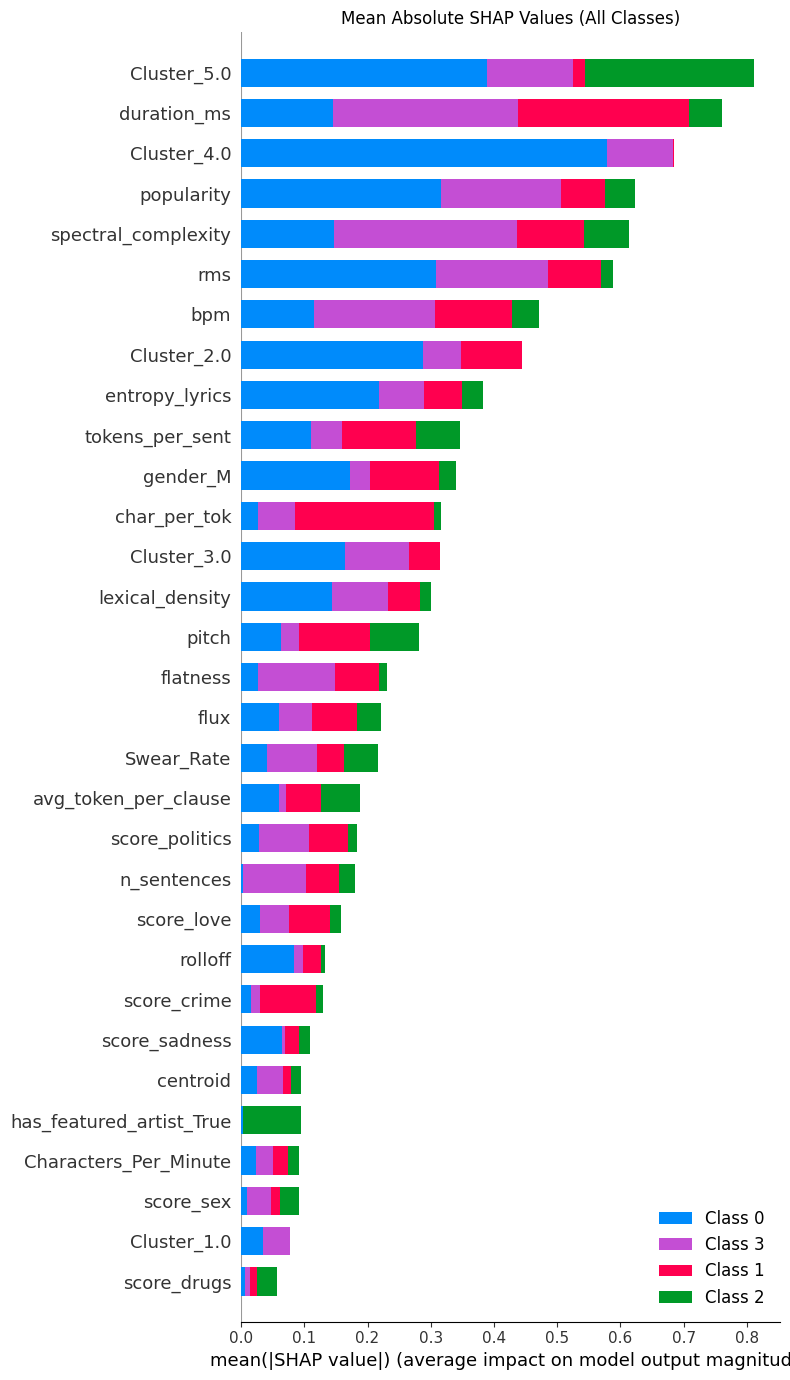

✅ Sliced Shape for Class 0: (1634, 31)


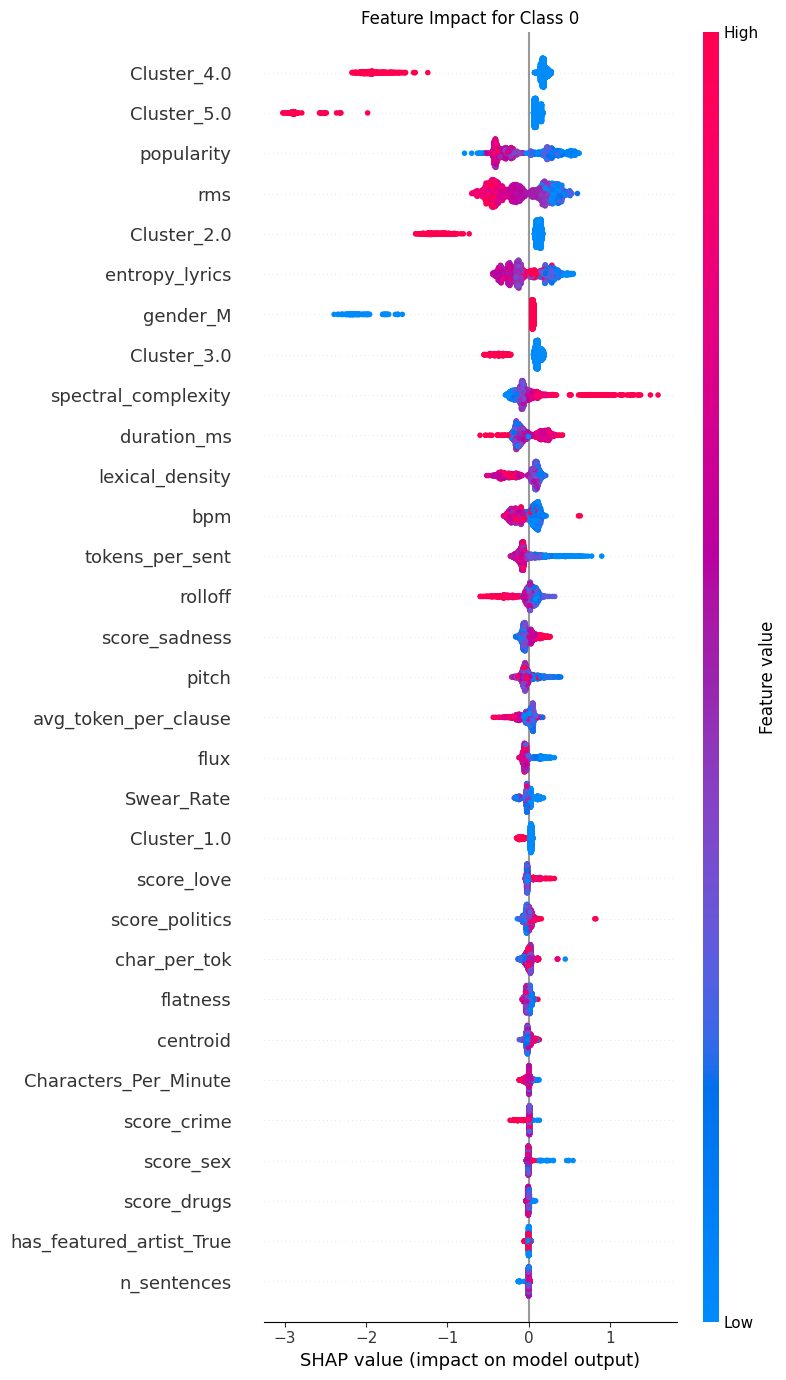

✅ Sliced Shape for Class 1: (1634, 31)


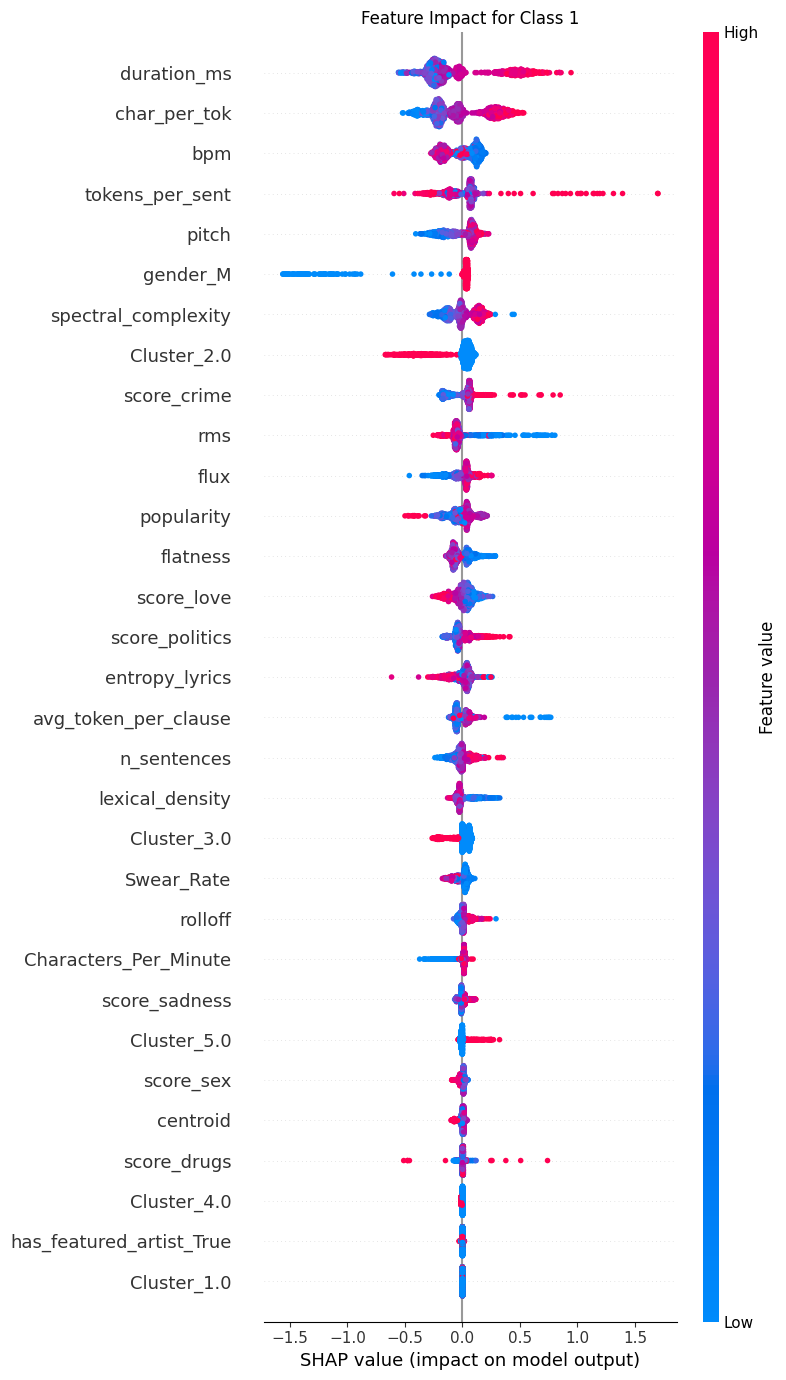

✅ Sliced Shape for Class 2: (1634, 31)


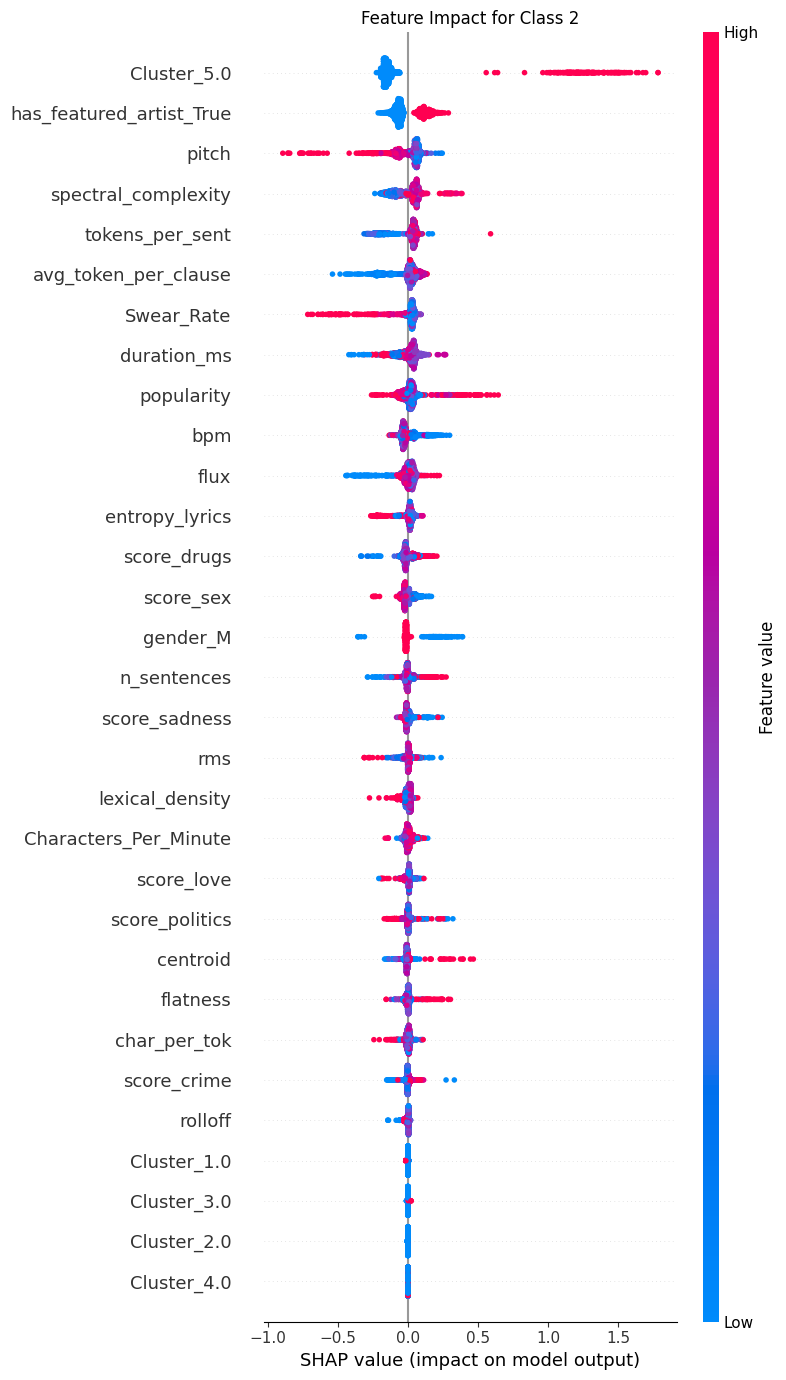

✅ Sliced Shape for Class 3: (1634, 31)


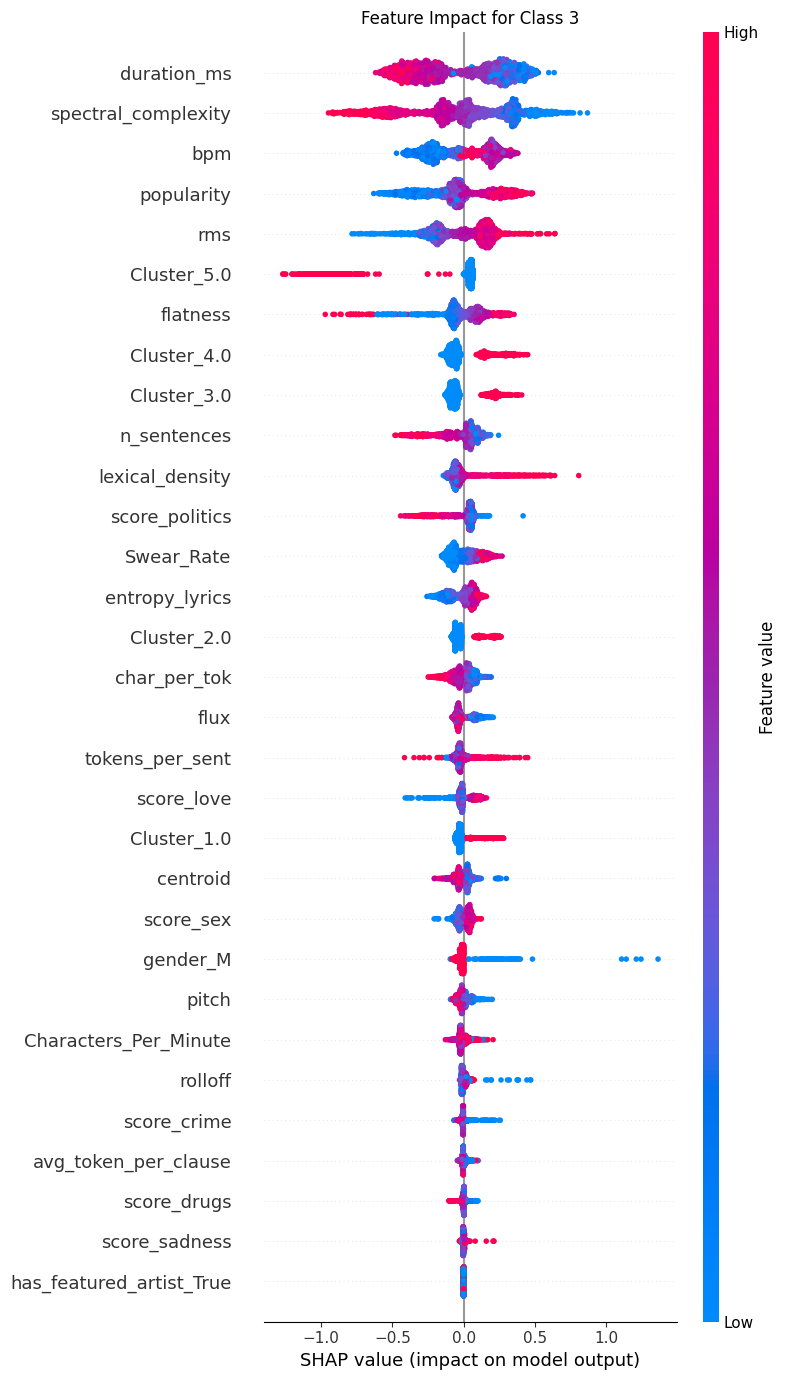

IndexError: index 4 is out of bounds for axis 2 with size 4

In [107]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
# XGBoost is a tree-based model, so we use TreeExplainer (optimized for trees)

explainer = shap.TreeExplainer(best_model_grid_xgb)

# 2. Calculate SHAP Values
# We use a subsample of X_test (e.g., first 200 rows) to speed up calculation
# If your dataset is small (<2000 rows), you can use the whole X_test
X_sample = X_test
shap_values = explainer.shap_values(X_sample)

# 3. Summary Plot (The "Beeswarm" Plot)
# For Multiclass problems, shap_values is a list of arrays (one per class).
# We can plot the summary for a SPECIFIC class (e.g., Class 0 = Center).
# Or use plot_type="bar" to see the aggregate importance across ALL classes.

print("📊 SHAP Summary Plot (Global Feature Importance)")
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=COLS,
    max_display=len(COLS),
    plot_type="bar", # 'bar' stacks the importance of all classes
    show=False
)
plt.title("Mean Absolute SHAP Values (All Classes)")
plt.tight_layout()
plt.show()

# 1. Define the class you want to explain (e.g., 0 for the first region)

for i in range (0, 5):
    # 2. Slice the 3D array correctly: [All Samples, All Features, Specific Class]
    # This transforms (2156, 35, 5) -> (2156, 35) matching X_sample
    class_shap_values = shap_values[:, :, i]

    print(f"✅ Sliced Shape for Class {i}: {class_shap_values.shape}")
    # Should output: (2156, 35)

    # 3. Plot
    plt.figure()
    shap.summary_plot(
        class_shap_values,
        X_sample,
        feature_names=COLS,
        max_display=len(COLS),
        show=False
    )
    plt.title(f"Feature Impact for Class {i}")
    plt.tight_layout()
    plt.show()